# Calculative Foundation
### Linear Algebra Analysis on Student Performance Dataset
**Dataset:** student_performance.csv

## Importing Libraries and Loading Dataset

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("student_performance.csv")
print(df.shape)
df.head()

(200, 8)


,Student_ID,Math,Science,English,History,Computer,Average_Score,Category
0,STU0001,49,77,84,44,80,66.8,Below Average
1,STU0002,55,52,67,74,78,65.2,Below Average
2,STU0003,96,84,91,65,93,85.8,Above Average
3,STU0004,44,75,98,46,75,67.6,Below Average
4,STU0005,88,74,75,93,79,81.8,Above Average


---
## Part A - Vector and Matrix Fundamentals

### Representing each student's subject scores as a vector

In [2]:
# Each student's scores = one vector [Math, Science, English, History, Computer]
subjects = ["Math", "Science", "English", "History", "Computer"]

v1 = np.array(df[subjects].iloc[0])
v2 = np.array(df[subjects].iloc[1])

print("Student 1 vector (STU0001):", v1)
print("Student 2 vector (STU0002):", v2)

Student 1 vector (STU0001): [49 77 84 44 80]
Student 2 vector (STU0002): [55 52 67 74 78]


### Norm-1 and Norm-2 of vectors

In [3]:
norm1_v1 = np.linalg.norm(v1, ord=1)
norm2_v1 = np.linalg.norm(v1, ord=2)

norm1_v2 = np.linalg.norm(v2, ord=1)
norm2_v2 = np.linalg.norm(v2, ord=2)

print("Student 1 - Norm 1:", norm1_v1)
print("Student 1 - Norm 2:", norm2_v1)
print()
print("Student 2 - Norm 1:", norm1_v2)
print("Student 2 - Norm 2:", norm2_v2)

Student 1 - Norm 1: 334.0
Student 1 - Norm 2: 154.0194792875239

Student 2 - Norm 1: 326.0
Student 2 - Norm 2: 147.57371039585607


### Dot Product and Angle between two student score vectors

In [4]:
dot = np.dot(v1, v2)
print("Dot Product of Student 1 and Student 2:", dot)

cos_angle = dot / (np.linalg.norm(v1) * np.linalg.norm(v2))
angle = np.degrees(np.arccos(cos_angle))
print("Angle between the two vectors:", angle, "degrees")

Dot Product of Student 1 and Student 2: 21823
Angle between the two vectors: 16.23368819990215 degrees


### Cross Product (using first 3 subjects - Math, Science, English)

In [5]:
v1_3d = v1[:3]
v2_3d = v2[:3]

cross = np.cross(v1_3d, v2_3d)
print("Student 1 (3D):", v1_3d)
print("Student 2 (3D):", v2_3d)
print("Cross Product:", cross)

Student 1 (3D): [49 77 84]
Student 2 (3D): [55 52 67]
Cross Product: [  791  1337 -1687]


### Projection of one vector onto another

In [6]:
projection = (np.dot(v1, v2) / np.dot(v2, v2)) * v2
print("Projection of Student 1 onto Student 2:")
print(projection)

Projection of Student 1 onto Student 2:
[55.1136468  52.10744788 67.13844246 74.1529066  78.16117182]


---
## Part B - Matrix Operations

### Forming a matrix of students x subjects (first 5 students)

In [7]:
matrix = df[subjects].head(5).values
print("Student Score Matrix (5 x 5):")
print(matrix)

Student Score Matrix (5 x 5):
[[49 77 84 44 80]
 [55 52 67 74 78]
 [96 84 91 65 93]
 [44 75 98 46 75]
 [88 74 75 93 79]]


### Matrix Addition and Multiplication

In [8]:
A = df[subjects].iloc[0:5].values
B = df[subjects].iloc[5:10].values

addition = A + B
print("Matrix Addition (Student 1-5 + Student 6-10):")
print(addition)

multiplication = np.dot(A, B.T)
print()
print("Matrix Multiplication (A x B.T):")
print(multiplication)

Matrix Addition (Student 1-5 + Student 6-10):
[[137 135 153 141 133]
 [151 118 142 153 162]
 [171 155 135 140 163]
 [118 163 148 126 147]
 [177 129 139 163 164]]

Matrix Multiplication (A x B.T):
[[23082 26282 21738 23882 23852]
 [23791 26135 21775 23532 23853]
 [30833 34532 28553 30942 31443]
 [23421 26458 21637 23836 23908]
 [30419 32940 27659 29902 29927]]


### Transpose of the matrix

In [9]:
transpose = matrix.T
print("Original Matrix Shape:", matrix.shape)
print("Transposed Matrix Shape:", transpose.shape)
print()
print("Transposed Matrix:")
print(transpose)

Original Matrix Shape: (5, 5)
Transposed Matrix Shape: (5, 5)

Transposed Matrix:
[[49 55 96 44 88]
 [77 52 84 75 74]
 [84 67 91 98 75]
 [44 74 65 46 93]
 [80 78 93 75 79]]


### Inverse and Determinant of the matrix

In [10]:
det = np.linalg.det(matrix)
print("Determinant of the matrix:", det)

if abs(det) > 1e-6:
    inverse = np.linalg.inv(matrix)
    print()
    print("Inverse of the matrix:")
    print(inverse)
else:
    print("Matrix is singular, inverse does not exist")

Determinant of the matrix: 49953296.0

Inverse of the matrix:
[[-0.02935278 -0.00679283  0.03224786  0.00377124 -0.00511179]
 [ 0.06764551 -0.04239488 -0.03251948 -0.02818957  0.03840113]
 [-0.06069501  0.00442533  0.01412894  0.05528736 -0.01202681]
 [-0.00341999  0.00439723 -0.02485069  0.00469647  0.02391766]
 [ 0.03098054  0.0379006   0.01038068 -0.03581221 -0.03435667]]


---
## Part C - Linear Transformations and Geometry

### Line, Plane and Hyperplane explanation with dataset

In [11]:
# Line - 1D: single subject score like Math
# A line represents one feature/dimension
print("Line (1D) - Math scores of first 5 students:")
print(df["Math"].head(5).values)

# Plane - 2D: two subject scores like Math and Science
print()
print("Plane (2D) - Math and Science scores of first 5 students:")
print(df[["Math", "Science"]].head(5).values)

# Hyperplane - 5D: all 5 subject scores together
print()
print("Hyperplane (5D) - All subject scores of first 5 students:")
print(df[subjects].head(5).values)

Line (1D) - Math scores of first 5 students:
[49 55 96 44 88]

Plane (2D) - Math and Science scores of first 5 students:
[[49 77]
 [55 52]
 [96 84]
 [44 75]
 [88 74]]

Hyperplane (5D) - All subject scores of first 5 students:
[[49 77 84 44 80]
 [55 52 67 74 78]
 [96 84 91 65 93]
 [44 75 98 46 75]
 [88 74 75 93 79]]


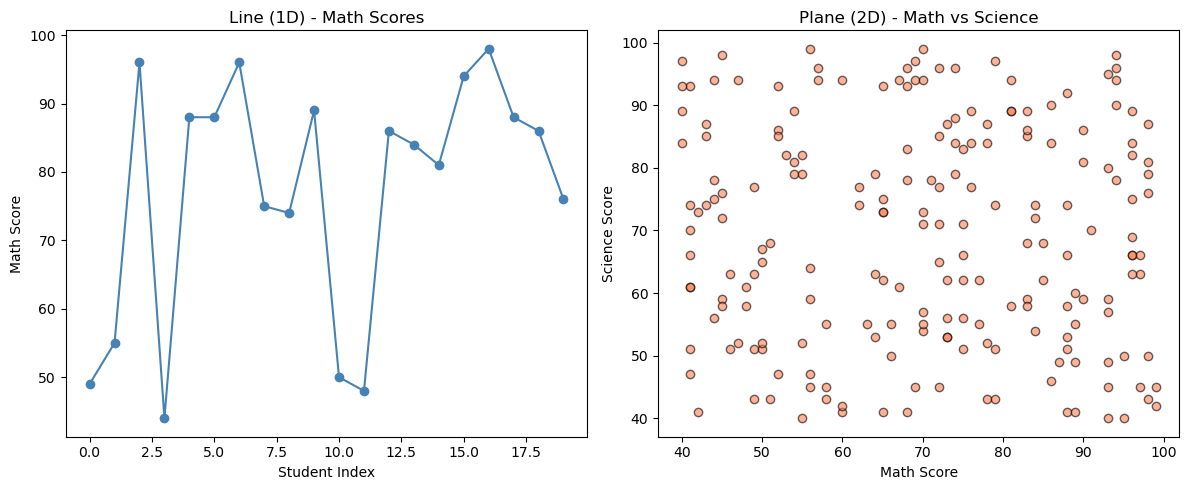

In [12]:
# Visualizing Line and Plane
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Line - 1D
axes[0].plot(df["Math"].head(20).values, marker="o", color="steelblue")
axes[0].set_title("Line (1D) - Math Scores")
axes[0].set_xlabel("Student Index")
axes[0].set_ylabel("Math Score")

# Plane - 2D
axes[1].scatter(df["Math"], df["Science"], color="coral", edgecolors="black", alpha=0.6)
axes[1].set_title("Plane (2D) - Math vs Science")
axes[1].set_xlabel("Math Score")
axes[1].set_ylabel("Science Score")

plt.tight_layout()
plt.show()

### Dimensionality increase from 2D to 3D to higher dimensions

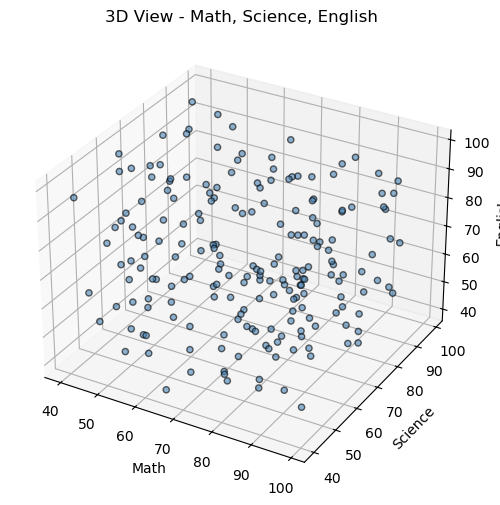

2D uses Math and Science
3D adds English as the third dimension
5D (Hyperplane) uses all 5 subjects together


In [13]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(df["Math"], df["Science"], df["English"],
           c="steelblue", edgecolors="black", alpha=0.6)
ax.set_title("3D View - Math, Science, English")
ax.set_xlabel("Math")
ax.set_ylabel("Science")
ax.set_zlabel("English")
plt.show()

print("2D uses Math and Science")
print("3D adds English as the third dimension")
print("5D (Hyperplane) uses all 5 subjects together")

---
## Part D - Eigenvalues and Decomposition

### Eigenvalues and Eigenvectors of the Covariance Matrix

In [14]:
score_matrix = df[subjects].values
cov_matrix = np.cov(score_matrix.T)

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Covariance Matrix Shape:", cov_matrix.shape)
print()
print("Eigenvalues:")
print(eigenvalues)
print()
print("Eigenvectors:")
print(eigenvectors)

Covariance Matrix Shape: (5, 5)

Eigenvalues:
[373.40144751 228.8391487  270.60243424 314.60001956 301.80893492]

Eigenvectors:
[[ 0.4836046  -0.01475139  0.22872366 -0.8272733   0.17091919]
 [-0.32063546 -0.1562908   0.2956304   0.07944518  0.88264218]
 [-0.53942797  0.32130168  0.6667198  -0.20773736 -0.34367512]
 [ 0.34447982 -0.62980066  0.57685774  0.32887336 -0.20919427]
 [ 0.50365724  0.68954474  0.2881111   0.39748567  0.17278479]]


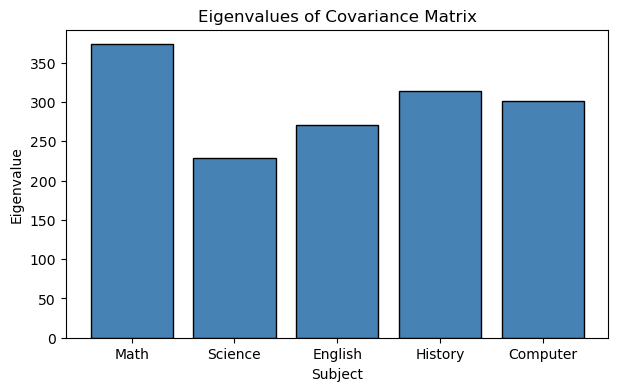

In [15]:
plt.figure(figsize=(7, 4))
plt.bar(subjects, eigenvalues.real, color="steelblue", edgecolor="black")
plt.title("Eigenvalues of Covariance Matrix")
plt.xlabel("Subject")
plt.ylabel("Eigenvalue")
plt.show()

### LU Decomposition of the dataset matrix

In [16]:
from scipy.linalg import lu

small_matrix = df[subjects].head(5).values.astype(float)

P, L, U = lu(small_matrix)

print("Original Matrix:")
print(small_matrix)
print()
print("P (Permutation Matrix):")
print(P)
print()
print("L (Lower Triangular):")
print(L)
print()
print("U (Upper Triangular):")
print(U)

Original Matrix:
[[49. 77. 84. 44. 80.]
 [55. 52. 67. 74. 78.]
 [96. 84. 91. 65. 93.]
 [44. 75. 98. 46. 75.]
 [88. 74. 75. 93. 79.]]

P (Permutation Matrix):
[[0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0.]]

L (Lower Triangular):
[[ 1.          0.          0.          0.          0.        ]
 [ 0.45833333  1.          0.          0.          0.        ]
 [ 0.51041667  0.93493151  1.          0.          0.        ]
 [ 0.91666667 -0.08219178  0.25137708  1.          0.        ]
 [ 0.57291667  0.10616438 -0.58954362  0.90649409  1.        ]]

U (Upper Triangular):
[[ 96.          84.          91.          65.          93.        ]
 [  0.          36.5         56.29166667  16.20833333  32.375     ]
 [  0.           0.         -15.07676941  -4.33076484   2.26284247]
 [  0.           0.           0.          35.83751349  -4.15786784]
 [  0.           0.           0.           0.          26.38480505]]


### Singular Value Decomposition (SVD)

U matrix shape: (200, 5)
Singular Values: [2222.9350547   270.81567576  250.05806877  243.83865881  213.52583702]
Vt matrix shape: (5, 5)


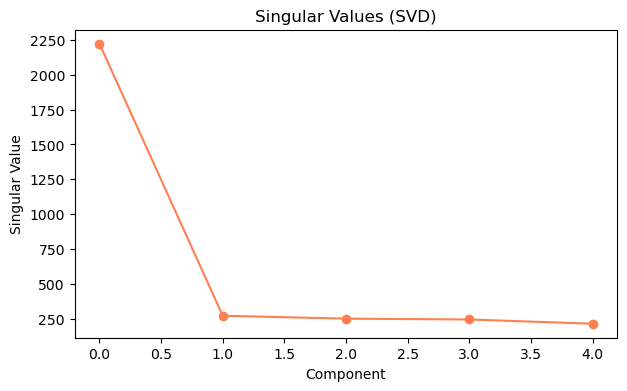


SVD helps in dimensionality reduction by keeping only the top singular values


In [17]:
score_data = df[subjects].values.astype(float)

U_mat, S, Vt = np.linalg.svd(score_data, full_matrices=False)

print("U matrix shape:", U_mat.shape)
print("Singular Values:", S)
print("Vt matrix shape:", Vt.shape)

plt.figure(figsize=(7, 4))
plt.plot(S, marker="o", color="coral")
plt.title("Singular Values (SVD)")
plt.xlabel("Component")
plt.ylabel("Singular Value")
plt.show()

print()
print("SVD helps in dimensionality reduction by keeping only the top singular values")

---
## Part E - Dimensionality Reduction

### PCA - Reducing dataset from 5 subjects to 2 dimensions

In [18]:
score_data = df[subjects].values

pca = PCA(n_components=2)
pca_result = pca.fit_transform(score_data)

print("Original shape:", score_data.shape)
print("After PCA shape:", pca_result.shape)
print()
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Explained:", sum(pca.explained_variance_ratio_))

Original shape: (200, 5)
After PCA shape: (200, 2)

Explained Variance Ratio: [0.25073087 0.211247  ]
Total Variance Explained: 0.4619778748203126


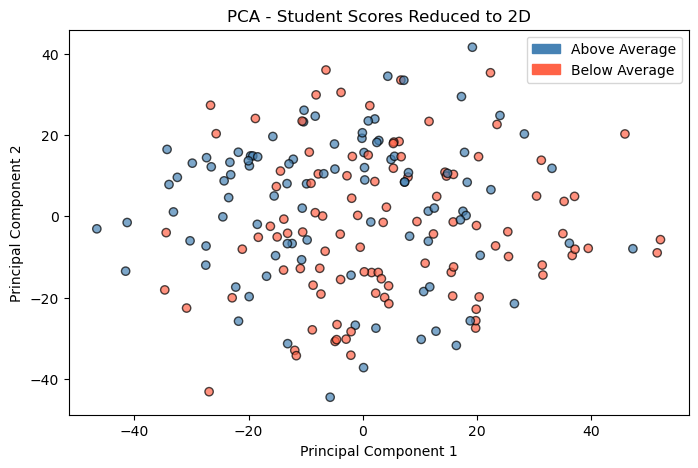

In [19]:
plt.figure(figsize=(8, 5))
colors = ["steelblue" if c == "Above Average" else "tomato" for c in df["Category"]]
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=colors, edgecolors="black", alpha=0.7)
plt.title("PCA - Student Scores Reduced to 2D")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

import matplotlib.patches as mpatches
above = mpatches.Patch(color="steelblue", label="Above Average")
below = mpatches.Patch(color="tomato", label="Below Average")
plt.legend(handles=[above, below])
plt.show()

### LDA - Classifying students into Above Average and Below Average

In [20]:
le = LabelEncoder()
labels = le.fit_transform(df["Category"])

lda = LDA(n_components=1)
lda_result = lda.fit_transform(score_data, labels)

print("Original shape:", score_data.shape)
print("After LDA shape:", lda_result.shape)

Original shape: (200, 5)
After LDA shape: (200, 1)


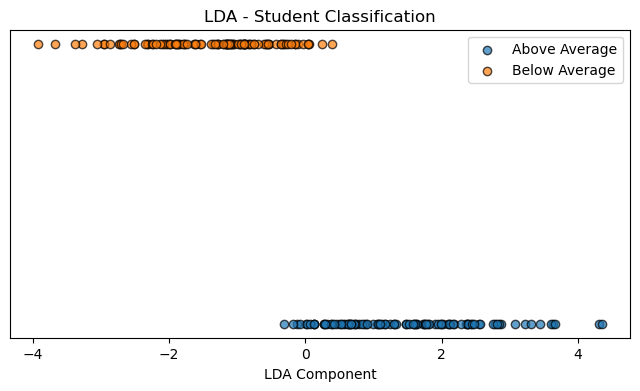

In [21]:
plt.figure(figsize=(8, 4))
for i, cat in enumerate(["Above Average", "Below Average"]):
    idx = df["Category"] == cat
    plt.scatter(lda_result[idx], np.zeros(idx.sum()) + i * 0.1,
                label=cat, alpha=0.7, edgecolors="black")
plt.title("LDA - Student Classification")
plt.xlabel("LDA Component")
plt.yticks([])
plt.legend()
plt.show()